# Pipeline Evaluation Dashboard

**Objective:** Compare six pipelines on a 200-call labeled test set

| Pipeline | Metric Predicted | Architecture |
|----------|-----------------|-------------|
| **Unified** (Hybrid RAG) | PCS + NPS | BGE-M3 + RAPTOR + HyDE + GPT-5-mini rationale |
| **PCS_LLM** | PCS | Direct GPT-5-mini structured output |
| **NPS_LLM** | NPS | Direct GPT-5-mini structured output |
| **PCS_XGBoost** | PCS | GPT-5-mini feature extraction + XGBoost regression |
| **NPS_XGBoost** | NPS | GPT-5-mini feature extraction + XGBoost regression |

**Training/Test Split:**
- Training: 116 transcripts (non-eval set with consensus labels)
- Test: 200 transcripts (eval set with consensus ground truth labels)

**Evaluations:**
1. XGBoost model training with Optuna 5-fold CV hyperparameter tuning (NPS + PCS)
2. KDE density comparison grids (predicted vs ground truth)
3. Class distribution bar charts
4. Per-transcript metrics tables (token usage, timing, accuracy)
5. Comparison table (runtime, cost per transcript, macro-averaged precision)

In [2]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import optuna
from scipy import stats
from sklearn.metrics import (
    precision_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Output directory for saved figures
FIG_DIR = './evaluation_figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('Imports complete.')

Imports complete.


In [3]:
# --- Data Loading ---
EVAL_DIR = './eval_files'
GLM_DIR = f'{EVAL_DIR}/glm_parameterized'
RESULTS_DIR = './results_tables'

# Ground truth (200 labeled transcripts = TEST set)
gt_df = pd.read_csv(f'{EVAL_DIR}/eval_table709.csv')

# XGBoost feature extraction outputs (316 rows total: 116 train + 200 test)
nps_xgb_raw = pd.read_csv(f'{GLM_DIR}/nps_xgboost_output.csv')
pcs_xgb_raw = pd.read_csv(f'{GLM_DIR}/pcs_xgboost_output.csv')

# Unified pipeline results (with per-stage token breakdowns)
unified_df = pd.read_csv(f'{RESULTS_DIR}/hybrid_rag_results6.csv')

# LLM Driver results
nps_llm_df = pd.read_csv(f'{RESULTS_DIR}/NPS_LLMDriver_Results.csv')
pcs_llm_df = pd.read_csv(f'{RESULTS_DIR}/PCS_LLMDriver_Results.csv')

print(f'Ground truth (test): {gt_df.shape}')
print(f'NPS XGB features:    {nps_xgb_raw.shape}')
print(f'PCS XGB features:    {pcs_xgb_raw.shape}')
print(f'Unified pipeline:    {unified_df.shape}')
print(f'NPS LLM Driver:      {nps_llm_df.shape}')
print(f'PCS LLM Driver:      {pcs_llm_df.shape}')

Ground truth (test): (200, 4)
NPS XGB features:    (316, 36)
PCS XGB features:    (316, 39)
Unified pipeline:    (200, 28)
NPS LLM Driver:      (200, 18)
PCS LLM Driver:      (200, 16)


In [4]:
# --- Class Mapping Functions ---

def pcs_score_to_class(score):
    """Map PCS numeric score (0-10) to class."""
    if pd.isna(score):
        return None
    score = int(round(float(score)))
    if score <= 3:
        return 'Negative'
    elif score <= 6:
        return 'Neutral'
    else:
        return 'Positive'

def nps_score_to_class(score):
    """Map NPS numeric score (0-10) to class."""
    if pd.isna(score):
        return None
    score = int(round(float(score)))
    if score <= 4:
        return 'Detractor'
    elif score <= 6:
        return 'Passive'
    else:
        return 'Promoter'

print('Class mapping functions defined.')

Class mapping functions defined.


---
## 1. XGBoost Model Training (Optuna 5-Fold CV)

Train XGBoost regressors for PCS and NPS using 116 non-eval transcripts.
Hyperparameters are tuned with Optuna using 5-fold cross-validation (minimize MAE).
Models are then evaluated on the held-out 200-transcript test set.

In [5]:
# --- Train/Test Split ---
# The 316-row XGB output files contain both:
#   - 116 training transcripts (NOT in eval_table709)
#   - 200 test transcripts (IN eval_table709)

eval_ids = set(gt_df['AgentRecordingSessionID'])

# PCS split
pcs_train = pcs_xgb_raw[~pcs_xgb_raw['AgentRecordingSessionID'].isin(eval_ids)].copy()
pcs_test = pcs_xgb_raw[pcs_xgb_raw['AgentRecordingSessionID'].isin(eval_ids)].copy()

# NPS split
nps_train = nps_xgb_raw[~nps_xgb_raw['AgentRecordingSessionID'].isin(eval_ids)].copy()
nps_test = nps_xgb_raw[nps_xgb_raw['AgentRecordingSessionID'].isin(eval_ids)].copy()

print(f'PCS - Train: {len(pcs_train)}, Test: {len(pcs_test)}')
print(f'NPS - Train: {len(nps_train)}, Test: {len(nps_test)}')

PCS - Train: 116, Test: 200
NPS - Train: 116, Test: 200


In [6]:
# --- PCS XGBoost: Feature Preparation & Optuna Training ---

# PCS feature columns
pcs_feature_cols = [
    'pcs_features__agent_resolution_quality',
    'pcs_features__communication_quality',
    'pcs_features__ownership_level',
    'pcs_features__customer_effort_level',
    'pcs_features__agent_greeted_professionally',
    'pcs_features__agent_showed_empathy',
    'pcs_features__agent_acknowledged_customer_emotion',
    'pcs_features__agent_took_ownership',
    'pcs_features__agent_apologized_when_appropriate',
    'pcs_features__agent_explained_next_steps',
    'pcs_features__agent_set_expectations',
    'pcs_features__agent_used_clear_language',
    'pcs_features__agent_required_repeat_information',
    'pcs_features__agent_interrupted_customer',
    'pcs_features__agent_followed_process',
    'pcs_features__agent_deescalated_effectively',
    'pcs_features__agent_escalated_or_transferred_appropriately',
    'pcs_features__agent_closed_professionally',
    'pcs_features__agent_professionalism',
    'pcs_features__agent_empathy_strength',
    'pcs_features__agent_ownership_strength',
    'pcs_features__process_adherence_strength',
    'pcs_features__communication_clarity',
    'pcs_features__resolution_effectiveness',
    'pcs_features__deescalation_effectiveness',
    'pcs_features__overall_agent_impression_latent',
    'confidence__feature_extraction_confidence',
]

# Ordinal encoding for categorical PCS features
pcs_ordinal_maps = {
    'pcs_features__agent_resolution_quality': {
        'unknown / unclear': 0, 'unknown': 0, 'poor': 1, 'adequate': 2, 'good': 3, 'excellent': 4
    },
    'pcs_features__communication_quality': {
        'unknown / unclear': 0, 'unknown': 0, 'unclear': 1, 'acceptable': 2, 'clear': 3, 'exceptional': 4
    },
    'pcs_features__ownership_level': {
        'unknown / unclear': 0, 'unknown': 0, 'low': 1, 'moderate': 2, 'strong': 3
    },
    'pcs_features__customer_effort_level': {
        'unknown / unclear': 0, 'unknown': 0, 'high': 1, 'medium': 2, 'low': 3
    }
}

def encode_pcs_features(df):
    """Apply ordinal encoding to PCS categorical features, ensure numeric."""
    df = df.copy()
    for col, mapping in pcs_ordinal_maps.items():
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip().map(mapping).fillna(0).astype(int)
    for col in pcs_feature_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

# Encode
pcs_train_enc = encode_pcs_features(pcs_train)
pcs_test_enc = encode_pcs_features(pcs_test)

# Prepare X, y
pcs_target = 'pcs_consensus_score'
pcs_train_enc[pcs_target] = pd.to_numeric(pcs_train_enc[pcs_target], errors='coerce')
pcs_test_enc[pcs_target] = pd.to_numeric(pcs_test_enc[pcs_target], errors='coerce')

pcs_train_valid = pcs_train_enc[pcs_train_enc[pcs_target].notna()]
pcs_test_valid = pcs_test_enc[pcs_test_enc[pcs_target].notna()]

X_pcs_train = pcs_train_valid[pcs_feature_cols].values
y_pcs_train = pcs_train_valid[pcs_target].values
X_pcs_test = pcs_test_valid[pcs_feature_cols].values
y_pcs_test = pcs_test_valid[pcs_target].values

print(f'PCS Training samples: {len(X_pcs_train)}')
print(f'PCS Test samples: {len(X_pcs_test)}')

PCS Training samples: 116
PCS Test samples: 200


In [7]:
# --- PCS Optuna Hyperparameter Tuning (5-fold CV) ---

def pcs_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        **params
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_pcs_train, y_pcs_train,
                            cv=kf, scoring='neg_mean_absolute_error')
    return -scores.mean()

pcs_study = optuna.create_study(direction='minimize', study_name='pcs_xgb')
pcs_study.optimize(pcs_objective, n_trials=100, show_progress_bar=True)

print(f'Best PCS MAE (CV): {pcs_study.best_value:.4f}')
print(f'Best params: {pcs_study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

Best PCS MAE (CV): 0.4814
Best params: {'learning_rate': 0.019660237769113683, 'max_depth': 8, 'n_estimators': 54, 'subsample': 0.8133924618271345, 'colsample_bytree': 0.6505078001353445, 'reg_alpha': 5.241699303882857, 'reg_lambda': 0.5314656004182784, 'min_child_weight': 7}


In [8]:
# --- PCS: Train Final Model & Predict on Test Set ---

pcs_best_params = pcs_study.best_params
pcs_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    **pcs_best_params
)
pcs_model.fit(X_pcs_train, y_pcs_train)

# Predict on test set
pcs_xgb_preds = pcs_model.predict(X_pcs_test)
pcs_xgb_preds_clipped = np.clip(pcs_xgb_preds, 0, 10)

# Evaluate
pcs_mae = mean_absolute_error(y_pcs_test, pcs_xgb_preds_clipped)
pcs_rmse = np.sqrt(mean_squared_error(y_pcs_test, pcs_xgb_preds_clipped))
pcs_r2 = r2_score(y_pcs_test, pcs_xgb_preds_clipped)

print(f'PCS XGBoost Test Performance:')
print(f'  MAE:  {pcs_mae:.4f}')
print(f'  RMSE: {pcs_rmse:.4f}')
print(f'  R2:   {pcs_r2:.4f}')
print(f'  Prediction range: [{pcs_xgb_preds_clipped.min():.2f}, {pcs_xgb_preds_clipped.max():.2f}]')

PCS XGBoost Test Performance:
  MAE:  1.3700
  RMSE: 1.5729
  R2:   -0.6338
  Prediction range: [5.54, 6.10]


In [9]:
# --- NPS XGBoost: Feature Preparation ---

# NPS feature columns (all integer-encoded from LLM extraction)
nps_feature_cols = [
    'customer_sentiment__overall_sentiment_tone',
    'customer_sentiment__sentiment_trajectory',
    'customer_sentiment__explicit_satisfaction_expressed',
    'customer_sentiment__explicit_dissatisfaction_expressed',
    'customer_sentiment__customer_frustration_level',
    'brand_perception__explicit_brand_sentiment',
    'brand_perception__recommendation_signal',
    'brand_perception__competitive_mention',
    'brand_perception__loyalty_history_signal',
    'issue_context__call_reason_category',
    'issue_context__issue_severity',
    'issue_context__recurring_issue',
    'issue_context__number_of_issues_raised',
    'resolution_outcome__resolution_status',
    'resolution_outcome__customer_acknowledges_resolution',
    'resolution_outcome__resolution_satisfied',
    'resolution_outcome__effort_required_from_customer',
    'forward_looking__churn_risk_signal',
    'forward_looking__future_intent_expressed',
    'forward_looking__post_call_sentiment_prediction',
    'interaction_quality_impact__agent_impact_on_brand_sentiment',
    'interaction_quality_impact__agent_created_promoter_moment',
    'interaction_quality_impact__agent_created_detractor_moment',
    'confidence__feature_extraction_confidence',
]

# NPS features are already integer-encoded, just ensure numeric
def encode_nps_features(df):
    df = df.copy()
    for col in nps_feature_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

nps_train_enc = encode_nps_features(nps_train)
nps_test_enc = encode_nps_features(nps_test)

# Prepare X, y
nps_target = 'nps_consensus_score'
nps_train_enc[nps_target] = pd.to_numeric(nps_train_enc[nps_target], errors='coerce')
nps_test_enc[nps_target] = pd.to_numeric(nps_test_enc[nps_target], errors='coerce')

nps_train_valid = nps_train_enc[nps_train_enc[nps_target].notna()]
nps_test_valid = nps_test_enc[nps_test_enc[nps_target].notna()]

X_nps_train = nps_train_valid[nps_feature_cols].values
y_nps_train = nps_train_valid[nps_target].values
X_nps_test = nps_test_valid[nps_feature_cols].values
y_nps_test = nps_test_valid[nps_target].values

print(f'NPS Training samples: {len(X_nps_train)}')
print(f'NPS Test samples: {len(X_nps_test)}')

NPS Training samples: 116
NPS Test samples: 200


In [11]:
# --- NPS Optuna Hyperparameter Tuning (5-fold CV) ---

def nps_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        **params
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_nps_train, y_nps_train,
                            cv=kf, scoring='neg_mean_absolute_error')
    return -scores.mean()

nps_study = optuna.create_study(direction='minimize', study_name='nps_xgb')
nps_study.optimize(nps_objective, n_trials=100, show_progress_bar=True)

print(f'Best NPS MAE (CV): {nps_study.best_value:.4f}')
print(f'Best params: {nps_study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

Best NPS MAE (CV): 0.5812
Best params: {'learning_rate': 0.017521620153427654, 'max_depth': 8, 'n_estimators': 211, 'subsample': 0.9827433596084856, 'colsample_bytree': 0.7401600340040133, 'reg_alpha': 1.7023873168074017, 'reg_lambda': 0.0007557676000400815, 'min_child_weight': 5}


In [12]:
# --- NPS: Train Final Model & Predict on Test Set ---

nps_best_params = nps_study.best_params
nps_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    **nps_best_params
)
nps_model.fit(X_nps_train, y_nps_train)

# Predict on test set
nps_xgb_preds = nps_model.predict(X_nps_test)
nps_xgb_preds_clipped = np.clip(nps_xgb_preds, 0, 10)

# Evaluate
nps_mae = mean_absolute_error(y_nps_test, nps_xgb_preds_clipped)
nps_rmse = np.sqrt(mean_squared_error(y_nps_test, nps_xgb_preds_clipped))
nps_r2 = r2_score(y_nps_test, nps_xgb_preds_clipped)

print(f'NPS XGBoost Test Performance:')
print(f'  MAE:  {nps_mae:.4f}')
print(f'  RMSE: {nps_rmse:.4f}')
print(f'  R2:   {nps_r2:.4f}')
print(f'  Prediction range: [{nps_xgb_preds_clipped.min():.2f}, {nps_xgb_preds_clipped.max():.2f}]')

NPS XGBoost Test Performance:
  MAE:  1.0910
  RMSE: 1.4895
  R2:   0.5222
  Prediction range: [2.38, 7.39]


In [13]:
# --- Build Unified Evaluation DataFrame ---
# Merge all pipeline predictions with ground truth on the 200 test transcripts

eval_df = gt_df[['AgentRecordingSessionID', 'pcs_consensus_score', 'nps_consensus_score']].copy()
eval_df.columns = ['arsid', 'pcs_gt', 'nps_gt']
eval_df['pcs_gt_class'] = eval_df['pcs_gt'].apply(pcs_score_to_class)
eval_df['nps_gt_class'] = eval_df['nps_gt'].apply(nps_score_to_class)

# --- Unified pipeline ---
unified_merge = unified_df[['AgentRecordingSessionID', 'pcs_score', 'nps_score',
                            'token_count', 'processing_time_s',
                            'total_llm_tokens']].copy()
unified_merge.columns = ['arsid', 'unified_pcs', 'unified_nps',
                         'unified_token_count', 'unified_time_s',
                         'unified_total_llm_tokens']
eval_df = eval_df.merge(unified_merge, on='arsid', how='inner')

# --- NPS LLM Driver ---
nps_llm_merge = nps_llm_df[['AgentRecordingSessionID', 'score',
                            'prompt_tokens', 'cached_tokens',
                            'completion_tokens', 'total_tokens']].copy()
nps_llm_merge.columns = ['arsid', 'nps_llm_score',
                         'nps_llm_prompt_tok', 'nps_llm_cached_tok',
                         'nps_llm_completion_tok', 'nps_llm_total_tok']
eval_df = eval_df.merge(nps_llm_merge, on='arsid', how='inner')

# --- PCS LLM Driver ---
pcs_llm_merge = pcs_llm_df[['AgentRecordingSessionID', 'score',
                            'prompt_tokens', 'cached_tokens',
                            'completion_tokens', 'total_tokens']].copy()
pcs_llm_merge.columns = ['arsid', 'pcs_llm_score',
                         'pcs_llm_prompt_tok', 'pcs_llm_cached_tok',
                         'pcs_llm_completion_tok', 'pcs_llm_total_tok']
eval_df = eval_df.merge(pcs_llm_merge, on='arsid', how='inner')

# --- PCS XGBoost predictions ---
pcs_xgb_merge = pcs_test_valid[['AgentRecordingSessionID']].copy()
pcs_xgb_merge = pcs_xgb_merge.rename(columns={'AgentRecordingSessionID': 'arsid'})
pcs_xgb_merge['pcs_xgb_score'] = pcs_xgb_preds_clipped
eval_df = eval_df.merge(pcs_xgb_merge, on='arsid', how='inner')

# --- NPS XGBoost predictions ---
nps_xgb_merge = nps_test_valid[['AgentRecordingSessionID']].copy()
nps_xgb_merge = nps_xgb_merge.rename(columns={'AgentRecordingSessionID': 'arsid'})
nps_xgb_merge['nps_xgb_score'] = nps_xgb_preds_clipped
eval_df = eval_df.merge(nps_xgb_merge, on='arsid', how='inner')

# Ensure numeric
for col in ['unified_pcs', 'unified_nps', 'nps_llm_score', 'pcs_llm_score']:
    eval_df[col] = pd.to_numeric(eval_df[col], errors='coerce')

# Derive classes
eval_df['unified_pcs_class'] = eval_df['unified_pcs'].apply(pcs_score_to_class)
eval_df['unified_nps_class'] = eval_df['unified_nps'].apply(nps_score_to_class)
eval_df['nps_llm_class'] = eval_df['nps_llm_score'].apply(nps_score_to_class)
eval_df['pcs_llm_class'] = eval_df['pcs_llm_score'].apply(pcs_score_to_class)
eval_df['pcs_xgb_class'] = eval_df['pcs_xgb_score'].round().clip(0, 10).apply(pcs_score_to_class)
eval_df['nps_xgb_class'] = eval_df['nps_xgb_score'].round().clip(0, 10).apply(nps_score_to_class)

print(f'Final eval_df: {eval_df.shape}')
print(f'Columns: {list(eval_df.columns)}')
eval_df.head()

Final eval_df: (200, 28)
Columns: ['arsid', 'pcs_gt', 'nps_gt', 'pcs_gt_class', 'nps_gt_class', 'unified_pcs', 'unified_nps', 'unified_token_count', 'unified_time_s', 'unified_total_llm_tokens', 'nps_llm_score', 'nps_llm_prompt_tok', 'nps_llm_cached_tok', 'nps_llm_completion_tok', 'nps_llm_total_tok', 'pcs_llm_score', 'pcs_llm_prompt_tok', 'pcs_llm_cached_tok', 'pcs_llm_completion_tok', 'pcs_llm_total_tok', 'pcs_xgb_score', 'nps_xgb_score', 'unified_pcs_class', 'unified_nps_class', 'nps_llm_class', 'pcs_llm_class', 'pcs_xgb_class', 'nps_xgb_class']


,arsid,pcs_gt,nps_gt,pcs_gt_class,nps_gt_class,unified_pcs,unified_nps,unified_token_count,unified_time_s,unified_total_llm_tokens,...,pcs_llm_completion_tok,pcs_llm_total_tok,pcs_xgb_score,nps_xgb_score,unified_pcs_class,unified_nps_class,nps_llm_class,pcs_llm_class,pcs_xgb_class,nps_xgb_class
0,0199B3D5A99E494F91D4755A4A3E4C1A,7,7,Positive,Promoter,7,8,1339,3.75,11370,...,254,2963,5.968672,6.935792,Positive,Promoter,Promoter,Positive,Neutral,Promoter
1,01C15847BA7F464AB935A29290D6CED6,8,6,Positive,Passive,7,8,690,3.75,6786,...,274,2127,6.041902,7.304749,Positive,Promoter,Promoter,Positive,Neutral,Promoter
2,01C4E68B33CE2442806918E1002B2609,7,7,Positive,Promoter,7,8,1699,3.75,12614,...,420,3583,5.783422,6.851570,Positive,Promoter,Promoter,Positive,Neutral,Promoter
3,01CA2971A26D9A4FAFF63FB639335A98,8,5,Positive,Passive,7,8,2401,3.75,15440,...,346,3927,5.970279,6.886823,Positive,Promoter,Promoter,Positive,Neutral,Promoter
4,01D040147C7CC840B4F31AE6AE673A12,7,7,Positive,Promoter,7,8,908,3.75,8482,...,246,2413,6.062681,7.043502,Positive,Promoter,Promoter,Positive,Neutral,Promoter


---
## 2. KDE Density Comparison Grids

Kernel Density Estimation plots comparing score distributions across pipelines vs ground truth.
- Row 1: PCS pipelines (Unified, PCS_XGBoost, PCS_LLM) vs Ground Truth
- Row 2: NPS pipelines (Unified, NPS_XGBoost, NPS_LLM) vs Ground Truth

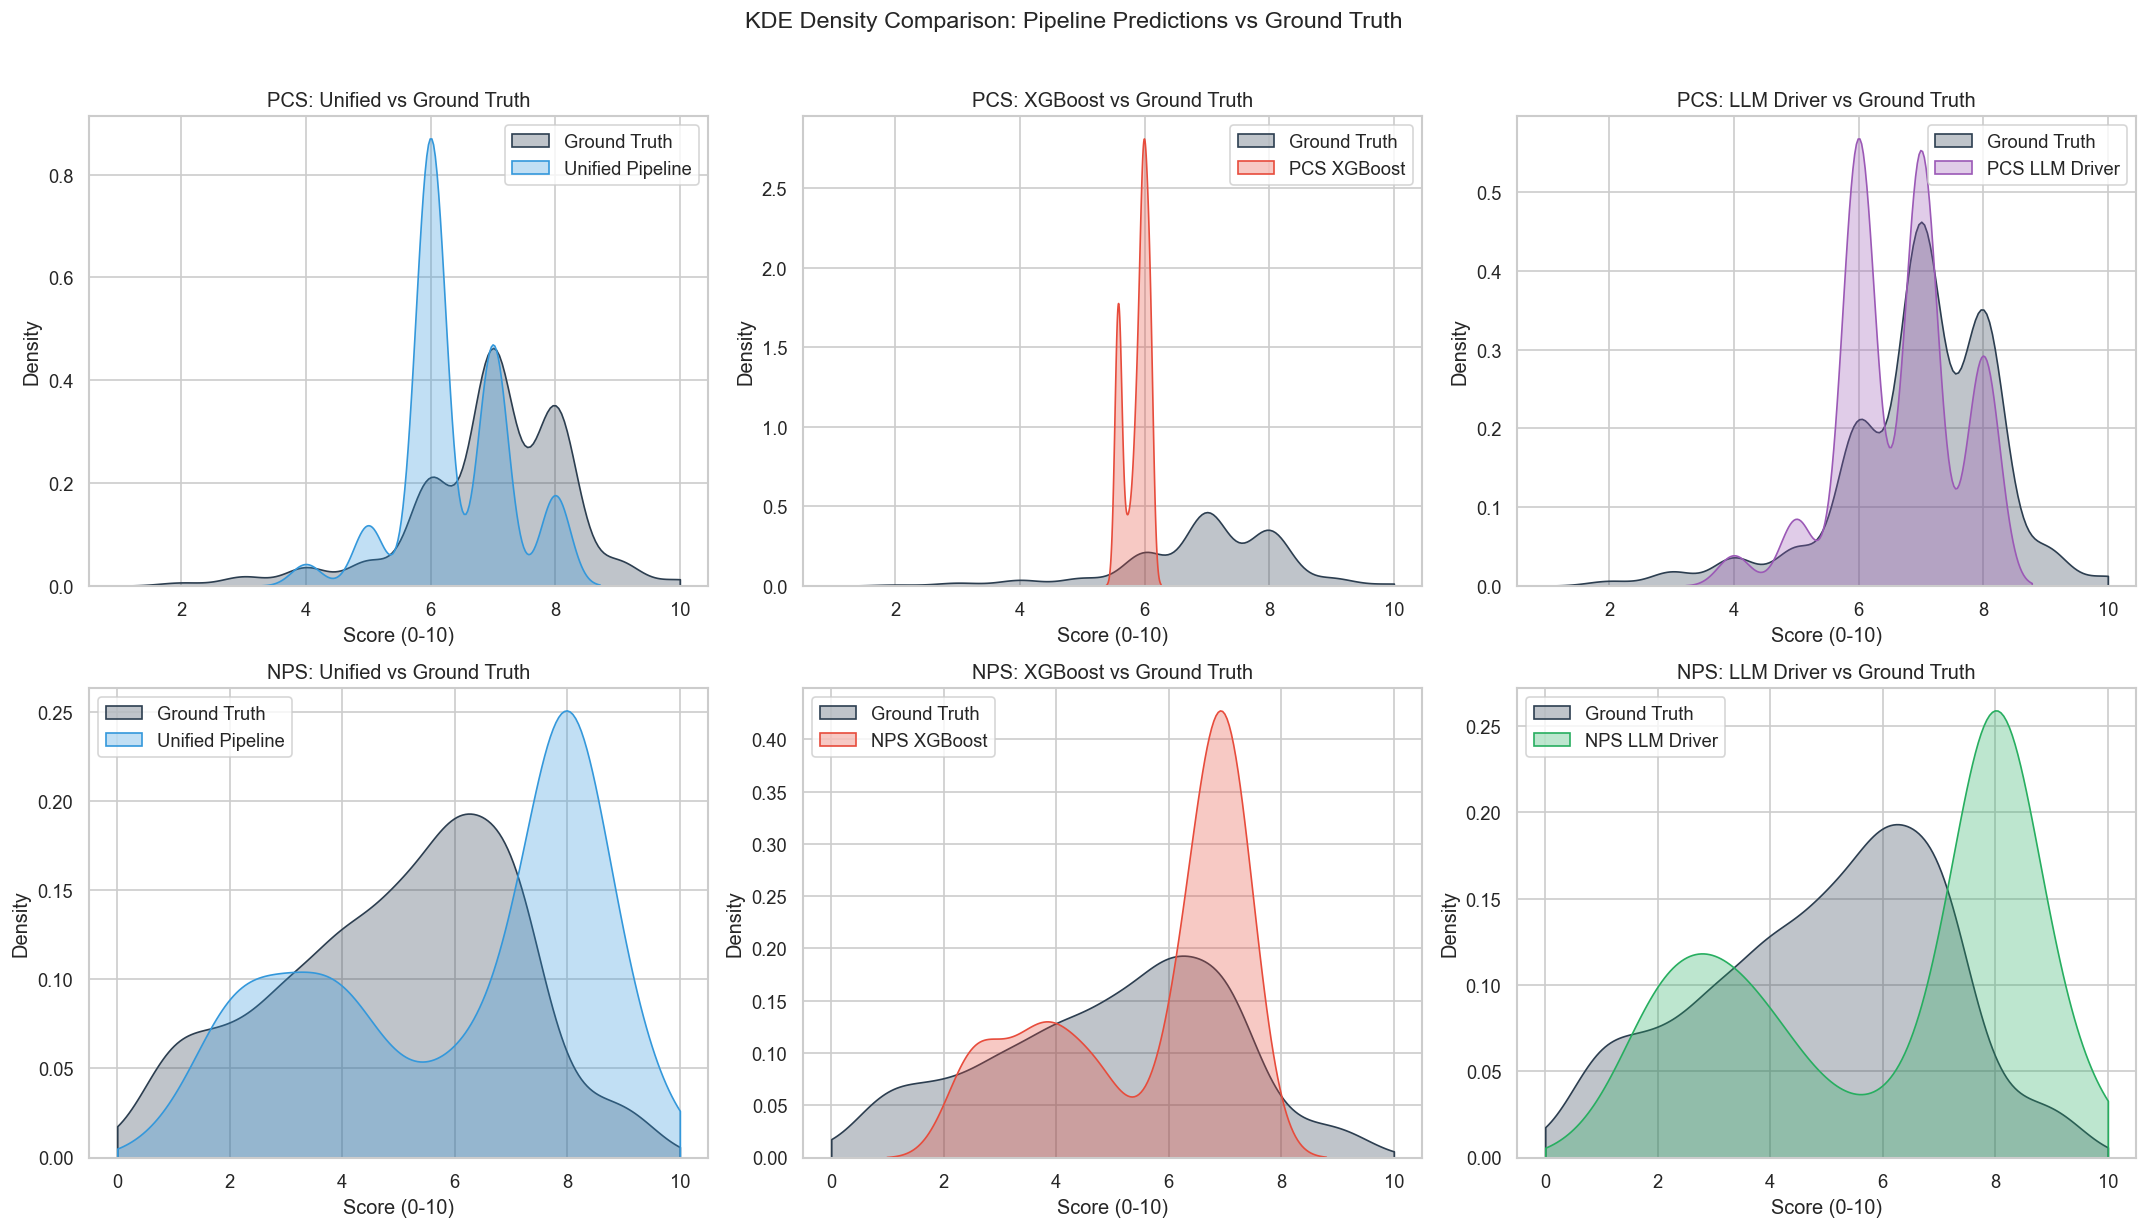

Saved: kde_density_grid.png


In [14]:
# --- KDE Density Comparison Grid ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

kde_kws = {'bw_adjust': 0.8, 'clip': (0, 10)}

# --- Row 1: PCS ---
# PCS: Unified vs GT
ax = axes[0, 0]
sns.kdeplot(eval_df['pcs_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['unified_pcs'].dropna(), ax=ax, label='Unified Pipeline',
            color='#3498db', fill=True, alpha=0.3, **kde_kws)
ax.set_title('PCS: Unified vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

# PCS: XGBoost vs GT
ax = axes[0, 1]
sns.kdeplot(eval_df['pcs_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['pcs_xgb_score'].dropna(), ax=ax, label='PCS XGBoost',
            color='#e74c3c', fill=True, alpha=0.3, **kde_kws)
ax.set_title('PCS: XGBoost vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

# PCS: LLM Driver vs GT
ax = axes[0, 2]
sns.kdeplot(eval_df['pcs_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['pcs_llm_score'].dropna(), ax=ax, label='PCS LLM Driver',
            color='#9b59b6', fill=True, alpha=0.3, **kde_kws)
ax.set_title('PCS: LLM Driver vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

# --- Row 2: NPS ---
# NPS: Unified vs GT
ax = axes[1, 0]
sns.kdeplot(eval_df['nps_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['unified_nps'].dropna(), ax=ax, label='Unified Pipeline',
            color='#3498db', fill=True, alpha=0.3, **kde_kws)
ax.set_title('NPS: Unified vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

# NPS: XGBoost vs GT
ax = axes[1, 1]
sns.kdeplot(eval_df['nps_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['nps_xgb_score'].dropna(), ax=ax, label='NPS XGBoost',
            color='#e74c3c', fill=True, alpha=0.3, **kde_kws)
ax.set_title('NPS: XGBoost vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

# NPS: LLM Driver vs GT
ax = axes[1, 2]
sns.kdeplot(eval_df['nps_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', fill=True, alpha=0.3, **kde_kws)
sns.kdeplot(eval_df['nps_llm_score'].dropna(), ax=ax, label='NPS LLM Driver',
            color='#27ae60', fill=True, alpha=0.3, **kde_kws)
ax.set_title('NPS: LLM Driver vs Ground Truth')
ax.set_xlabel('Score (0-10)')
ax.legend()

plt.suptitle('KDE Density Comparison: Pipeline Predictions vs Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/kde_density_grid.png', bbox_inches='tight')
plt.show()
print('Saved: kde_density_grid.png')

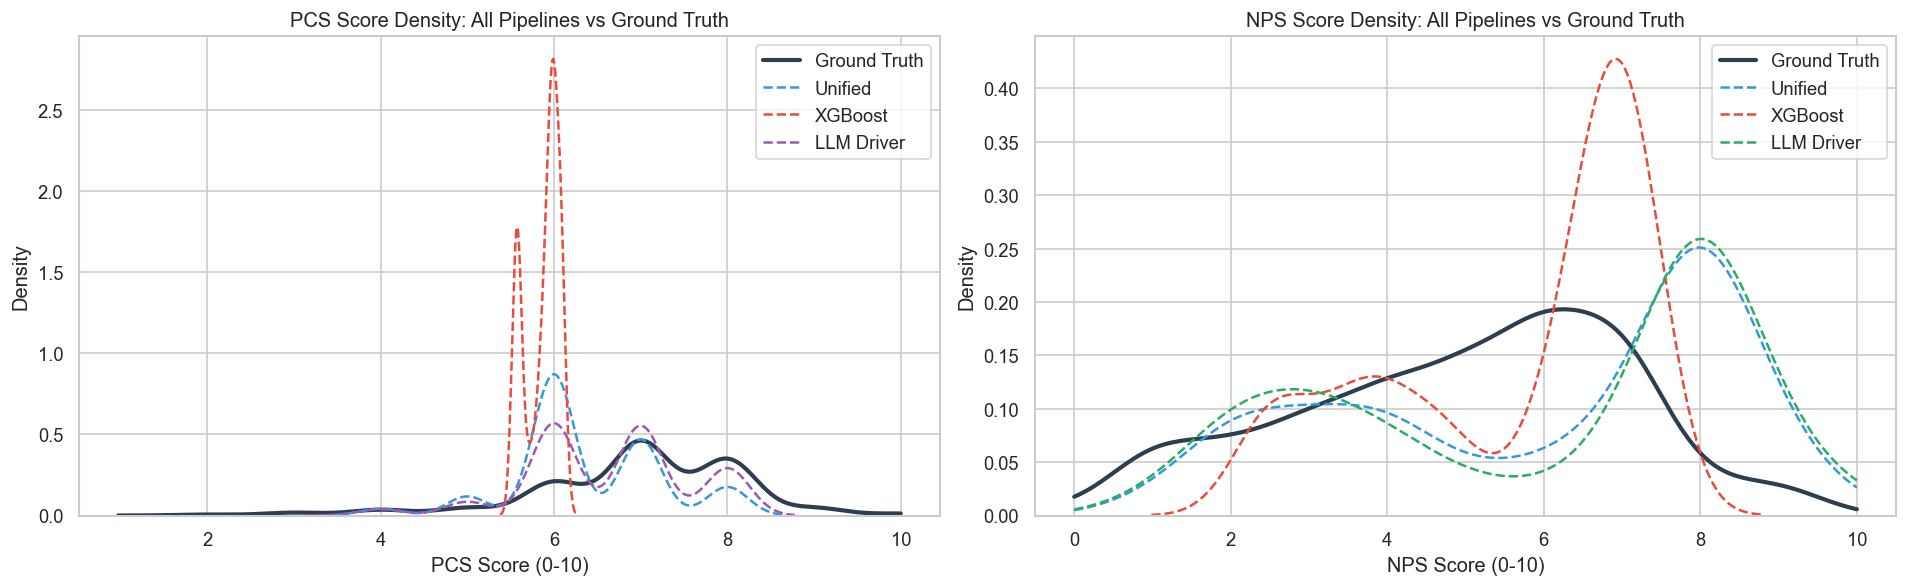

Saved: kde_overlay_all_pipelines.png


In [15]:
# --- Combined KDE Overlay (all pipelines on one plot per metric) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PCS overlay
ax = axes[0]
sns.kdeplot(eval_df['pcs_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', linewidth=2.5, **kde_kws)
sns.kdeplot(eval_df['unified_pcs'].dropna(), ax=ax, label='Unified',
            color='#3498db', linewidth=1.5, linestyle='--', **kde_kws)
sns.kdeplot(eval_df['pcs_xgb_score'].dropna(), ax=ax, label='XGBoost',
            color='#e74c3c', linewidth=1.5, linestyle='--', **kde_kws)
sns.kdeplot(eval_df['pcs_llm_score'].dropna(), ax=ax, label='LLM Driver',
            color='#9b59b6', linewidth=1.5, linestyle='--', **kde_kws)
ax.set_title('PCS Score Density: All Pipelines vs Ground Truth')
ax.set_xlabel('PCS Score (0-10)')
ax.legend()

# NPS overlay
ax = axes[1]
sns.kdeplot(eval_df['nps_gt'].dropna(), ax=ax, label='Ground Truth',
            color='#2c3e50', linewidth=2.5, **kde_kws)
sns.kdeplot(eval_df['unified_nps'].dropna(), ax=ax, label='Unified',
            color='#3498db', linewidth=1.5, linestyle='--', **kde_kws)
sns.kdeplot(eval_df['nps_xgb_score'].dropna(), ax=ax, label='XGBoost',
            color='#e74c3c', linewidth=1.5, linestyle='--', **kde_kws)
sns.kdeplot(eval_df['nps_llm_score'].dropna(), ax=ax, label='LLM Driver',
            color='#27ae60', linewidth=1.5, linestyle='--', **kde_kws)
ax.set_title('NPS Score Density: All Pipelines vs Ground Truth')
ax.set_xlabel('NPS Score (0-10)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/kde_overlay_all_pipelines.png', bbox_inches='tight')
plt.show()
print('Saved: kde_overlay_all_pipelines.png')

---
## 3. Class Distribution Bar Charts

Grouped bar charts comparing predicted class frequencies against ground truth.

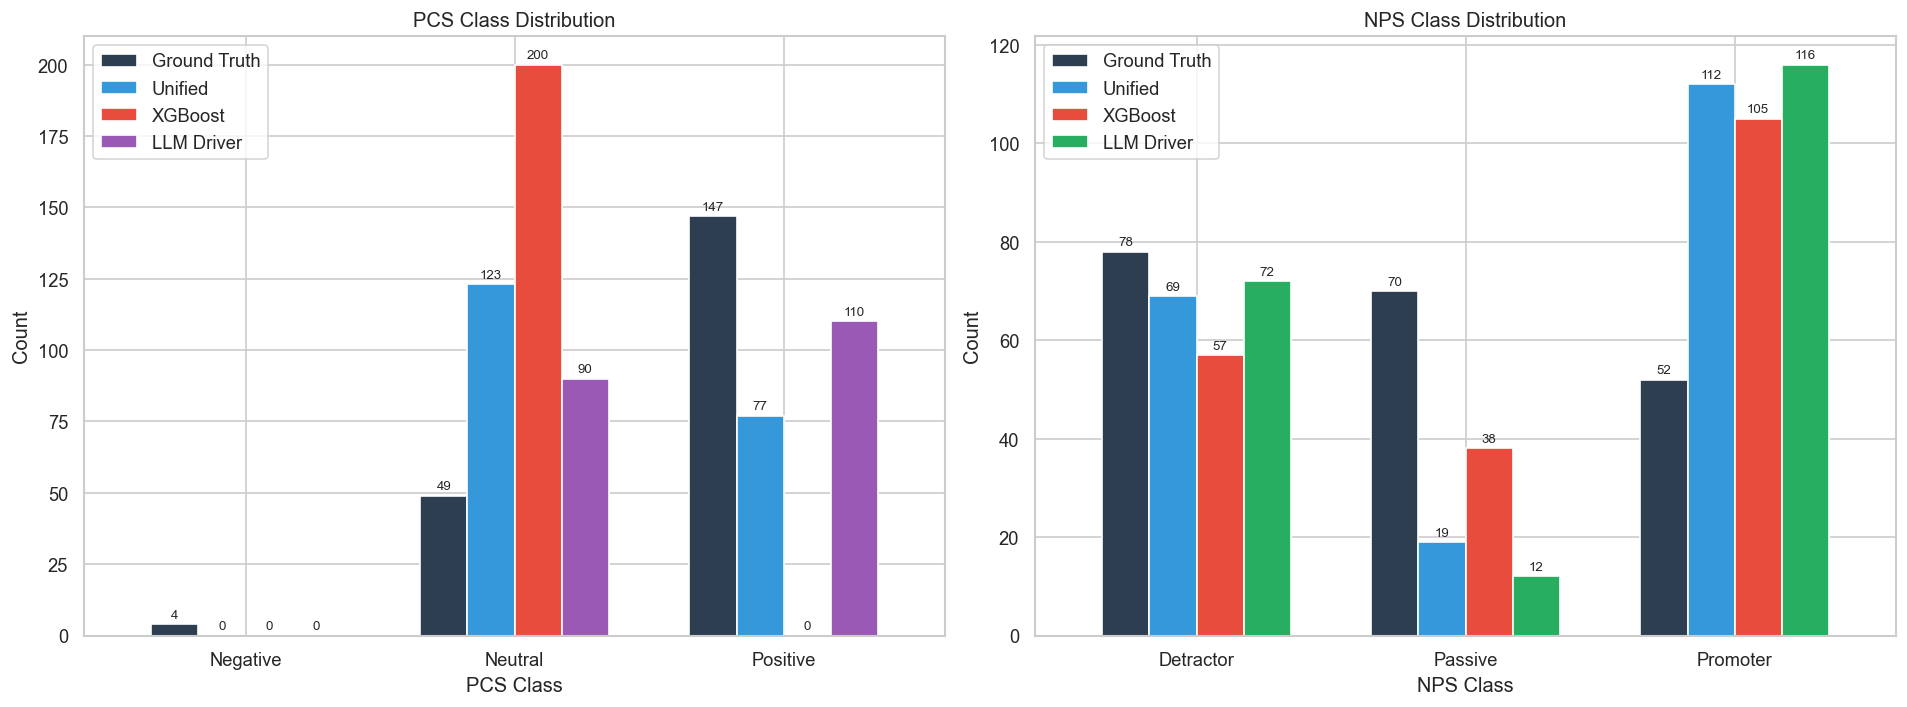

Saved: class_distributions.png


In [16]:
# --- Class Distribution Bar Charts ---
pcs_classes = ['Negative', 'Neutral', 'Positive']
nps_classes = ['Detractor', 'Passive', 'Promoter']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PCS ---
ax = axes[0]
pcs_counts = pd.DataFrame({
    'Ground Truth': eval_df['pcs_gt_class'].value_counts().reindex(pcs_classes, fill_value=0),
    'Unified': eval_df['unified_pcs_class'].value_counts().reindex(pcs_classes, fill_value=0),
    'XGBoost': eval_df['pcs_xgb_class'].value_counts().reindex(pcs_classes, fill_value=0),
    'LLM Driver': eval_df['pcs_llm_class'].value_counts().reindex(pcs_classes, fill_value=0),
})
pcs_counts.plot(kind='bar', ax=ax, width=0.7, edgecolor='white',
                color=['#2c3e50', '#3498db', '#e74c3c', '#9b59b6'])
ax.set_xlabel('PCS Class')
ax.set_ylabel('Count')
ax.set_title('PCS Class Distribution')
ax.set_xticklabels(pcs_classes, rotation=0)
ax.legend(loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

# --- NPS ---
ax = axes[1]
nps_counts = pd.DataFrame({
    'Ground Truth': eval_df['nps_gt_class'].value_counts().reindex(nps_classes, fill_value=0),
    'Unified': eval_df['unified_nps_class'].value_counts().reindex(nps_classes, fill_value=0),
    'XGBoost': eval_df['nps_xgb_class'].value_counts().reindex(nps_classes, fill_value=0),
    'LLM Driver': eval_df['nps_llm_class'].value_counts().reindex(nps_classes, fill_value=0),
})
nps_counts.plot(kind='bar', ax=ax, width=0.7, edgecolor='white',
                color=['#2c3e50', '#3498db', '#e74c3c', '#27ae60'])
ax.set_xlabel('NPS Class')
ax.set_ylabel('Count')
ax.set_title('NPS Class Distribution')
ax.set_xticklabels(nps_classes, rotation=0)
ax.legend(loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/class_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: class_distributions.png')

---
## 4. Pipeline Comparison Table

Runtime, cost per transcript, and macro-averaged precision across all pipelines.

**Cost model:** Azure OpenAI GPT-5-mini pricing
- Input: $0.40/1M tokens
- Cached input: $0.20/1M tokens
- Output: $1.60/1M tokens

In [17]:
# --- Pipeline Comparison Table ---

# Pricing constants
INPUT_PRICE = 0.40 / 1_000_000
CACHED_PRICE = 0.20 / 1_000_000
OUTPUT_PRICE = 1.60 / 1_000_000

def compute_cost(prompt, completion, cached=0):
    """Cost per transcript in USD."""
    uncached = prompt - cached
    return uncached * INPUT_PRICE + cached * CACHED_PRICE + completion * OUTPUT_PRICE

def macro_prec(y_true, y_pred, labels):
    """Macro-averaged precision, handles missing classes."""
    mask = pd.notna(y_true) & pd.notna(y_pred)
    return precision_score(y_true[mask], y_pred[mask], labels=labels,
                          average='macro', zero_division=0)

# --- Precision ---
prec_pcs_unified = macro_prec(eval_df['pcs_gt_class'], eval_df['unified_pcs_class'], pcs_classes)
prec_pcs_xgb = macro_prec(eval_df['pcs_gt_class'], eval_df['pcs_xgb_class'], pcs_classes)
prec_pcs_llm = macro_prec(eval_df['pcs_gt_class'], eval_df['pcs_llm_class'], pcs_classes)
prec_nps_unified = macro_prec(eval_df['nps_gt_class'], eval_df['unified_nps_class'], nps_classes)
prec_nps_xgb = macro_prec(eval_df['nps_gt_class'], eval_df['nps_xgb_class'], nps_classes)
prec_nps_llm = macro_prec(eval_df['nps_gt_class'], eval_df['nps_llm_class'], nps_classes)

# --- Cost ---
# NPS LLM Driver
nps_llm_cost = compute_cost(
    eval_df['nps_llm_prompt_tok'].mean(),
    eval_df['nps_llm_completion_tok'].mean(),
    eval_df['nps_llm_cached_tok'].mean()
)
# PCS LLM Driver
pcs_llm_cost = compute_cost(
    eval_df['pcs_llm_prompt_tok'].mean(),
    eval_df['pcs_llm_completion_tok'].mean(),
    eval_df['pcs_llm_cached_tok'].mean()
)
# Unified: uses total_llm_tokens (combined input+output)
unified_cost = eval_df['unified_total_llm_tokens'].mean() * INPUT_PRICE  # conservative estimate

# XGBoost pipelines: LLM cost is from feature extraction (same as respective LLM drivers)
# but only 1 call per transcript for feature extraction
# Parse debug_info from xgb raw for token usage
def parse_xgb_tokens(df):
    tokens = df['debug_info'].apply(lambda x: ast.literal_eval(x).get('usage', {}) if pd.notna(x) else {})
    return pd.DataFrame({
        'prompt': tokens.apply(lambda d: d.get('prompt_tokens', 0)),
        'completion': tokens.apply(lambda d: d.get('completion_tokens', 0)),
        'cached': tokens.apply(lambda d: d.get('cached_tokens', 0)),
    })

pcs_xgb_tokens = parse_xgb_tokens(pcs_test_valid)
nps_xgb_tokens = parse_xgb_tokens(nps_test_valid)

pcs_xgb_cost = compute_cost(
    pcs_xgb_tokens['prompt'].mean(),
    pcs_xgb_tokens['completion'].mean(),
    pcs_xgb_tokens['cached'].mean()
)
nps_xgb_cost = compute_cost(
    nps_xgb_tokens['prompt'].mean(),
    nps_xgb_tokens['completion'].mean(),
    nps_xgb_tokens['cached'].mean()
)

# --- Runtime ---
unified_time = eval_df['unified_time_s'].mean()

# Build table
comparison = pd.DataFrame({
    'Pipeline': ['Unified (PCS)', 'Unified (NPS)', 'PCS XGBoost', 'NPS XGBoost',
                 'PCS LLM Driver', 'NPS LLM Driver'],
    'Metric': ['PCS', 'NPS', 'PCS', 'NPS', 'PCS', 'NPS'],
    'Avg Runtime (s)': [f'{unified_time:.2f}*', f'{unified_time:.2f}*',
                        'N/A (batch)', 'N/A (batch)', 'N/A', 'N/A'],
    'Avg Cost/Transcript': [f'${unified_cost:.5f}*', f'${unified_cost:.5f}*',
                            f'${pcs_xgb_cost:.5f}', f'${nps_xgb_cost:.5f}',
                            f'${pcs_llm_cost:.5f}', f'${nps_llm_cost:.5f}'],
    'Macro Precision': [f'{prec_pcs_unified:.3f}', f'{prec_nps_unified:.3f}',
                        f'{prec_pcs_xgb:.3f}', f'{prec_nps_xgb:.3f}',
                        f'{prec_pcs_llm:.3f}', f'{prec_nps_llm:.3f}'],
    'MAE': [f'{(eval_df["unified_pcs"] - eval_df["pcs_gt"]).abs().mean():.3f}',
            f'{(eval_df["unified_nps"] - eval_df["nps_gt"]).abs().mean():.3f}',
            f'{pcs_mae:.3f}', f'{nps_mae:.3f}',
            f'{(eval_df["pcs_llm_score"] - eval_df["pcs_gt"]).abs().mean():.3f}',
            f'{(eval_df["nps_llm_score"] - eval_df["nps_gt"]).abs().mean():.3f}'],
})

print('=' * 80)
print('PIPELINE COMPARISON TABLE')
print('=' * 80)
display(comparison)
print('\n* Unified runtime/cost is for full pipeline (PCS + NPS combined in single call).')

PIPELINE COMPARISON TABLE


,Pipeline,Metric,Avg Runtime (s),Avg Cost/Transcript,Macro Precision,MAE
0,Unified (PCS),PCS,3.75*,$0.00461*,0.438,0.915
1,Unified (NPS),NPS,3.75*,$0.00461*,0.675,1.365
2,PCS XGBoost,PCS,N/A (batch),$0.00316,0.082,1.370
3,NPS XGBoost,NPS,N/A (batch),$0.00297,0.612,1.091
4,PCS LLM Driver,PCS,N/A,$0.00141,0.454,0.770
5,NPS LLM Driver,NPS,N/A,$0.00139,0.631,1.430



* Unified runtime/cost is for full pipeline (PCS + NPS combined in single call).


---
## 5. Per-Transcript Metrics Tables

Detailed per-transcript comparison of token usage, timing, and prediction accuracy across pipelines.

In [18]:
# --- Token Usage Summary Table ---

def token_stats(series, name):
    """Compute summary stats for a token series."""
    s = pd.to_numeric(series, errors='coerce').dropna()
    return {
        'Pipeline / Metric': name,
        'Mean': f'{s.mean():.0f}',
        'Median': f'{s.median():.0f}',
        'Min': f'{s.min():.0f}',
        'Max': f'{s.max():.0f}',
        'Std Dev': f'{s.std():.0f}',
        'Total (200 calls)': f'{s.sum():,.0f}',
    }

token_rows = [
    token_stats(eval_df['unified_total_llm_tokens'], 'Unified - Total LLM Tokens'),
    token_stats(eval_df['unified_token_count'], 'Unified - Input Token Count'),
    token_stats(eval_df['nps_llm_total_tok'], 'NPS LLM Driver - Total Tokens'),
    token_stats(eval_df['nps_llm_prompt_tok'], 'NPS LLM Driver - Prompt Tokens'),
    token_stats(eval_df['nps_llm_completion_tok'], 'NPS LLM Driver - Completion Tokens'),
    token_stats(eval_df['pcs_llm_total_tok'], 'PCS LLM Driver - Total Tokens'),
    token_stats(eval_df['pcs_llm_prompt_tok'], 'PCS LLM Driver - Prompt Tokens'),
    token_stats(eval_df['pcs_llm_completion_tok'], 'PCS LLM Driver - Completion Tokens'),
    token_stats(pcs_xgb_tokens['prompt'] + pcs_xgb_tokens['completion'], 'PCS XGBoost - Total Tokens'),
    token_stats(nps_xgb_tokens['prompt'] + nps_xgb_tokens['completion'], 'NPS XGBoost - Total Tokens'),
]

token_table = pd.DataFrame(token_rows)
print('=' * 80)
print('TOKEN USAGE SUMMARY (per transcript)')
print('=' * 80)
display(token_table)

TOKEN USAGE SUMMARY (per transcript)


,Pipeline / Metric,Mean,Median,Min,Max,Std Dev,Total (200 calls)
0,Unified - Total LLM Tokens,11531,9832,4174,46858,6404,"2,306,287"
1,Unified - Input Token Count,1669,1269,141,8184,1316,"333,890"
2,NPS LLM Driver - Total Tokens,3147,2752,1576,9665,1263,"629,443"
3,NPS LLM Driver - Prompt Tokens,2872,2490,1350,9378,1245,"574,312"
4,NPS LLM Driver - Completion Tokens,276,272,166,467,55,"55,131"
5,PCS LLM Driver - Total Tokens,3208,2822,1720,9745,1253,"641,597"
6,PCS LLM Driver - Prompt Tokens,2891,2509,1369,9397,1245,"578,112"
7,PCS LLM Driver - Completion Tokens,317,323,192,465,50,"63,485"
8,PCS XGBoost - Total Tokens,4694,4330,2917,11348,1295,"938,801"
9,NPS XGBoost - Total Tokens,4519,4119,2666,11354,1307,"903,852"


In [19]:
# --- Cache Rate Analysis ---

nps_llm_cache_rate = (eval_df['nps_llm_cached_tok'] / eval_df['nps_llm_prompt_tok']).replace([np.inf], 0).mean()
pcs_llm_cache_rate = (eval_df['pcs_llm_cached_tok'] / eval_df['pcs_llm_prompt_tok']).replace([np.inf], 0).mean()
pcs_xgb_cache_rate = (pcs_xgb_tokens['cached'] / pcs_xgb_tokens['prompt']).replace([np.inf], 0).mean()
nps_xgb_cache_rate = (nps_xgb_tokens['cached'] / nps_xgb_tokens['prompt']).replace([np.inf], 0).mean()

cache_df = pd.DataFrame({
    'Pipeline': ['NPS LLM Driver', 'PCS LLM Driver', 'PCS XGBoost', 'NPS XGBoost'],
    'Avg Cache Rate': [f'{nps_llm_cache_rate:.1%}', f'{pcs_llm_cache_rate:.1%}',
                       f'{pcs_xgb_cache_rate:.1%}', f'{nps_xgb_cache_rate:.1%}'],
})
print('\nCache Rate Summary:')
display(cache_df)


Cache Rate Summary:


,Pipeline,Avg Cache Rate
0,NPS LLM Driver,40.0%
1,PCS LLM Driver,48.4%
2,PCS XGBoost,53.4%
3,NPS XGBoost,51.3%


In [20]:
# --- Per-Transcript Accuracy Metrics ---

# Score-level error per transcript
eval_df['pcs_unified_err'] = (eval_df['unified_pcs'] - eval_df['pcs_gt']).abs()
eval_df['pcs_xgb_err'] = (eval_df['pcs_xgb_score'] - eval_df['pcs_gt']).abs()
eval_df['pcs_llm_err'] = (eval_df['pcs_llm_score'] - eval_df['pcs_gt']).abs()
eval_df['nps_unified_err'] = (eval_df['unified_nps'] - eval_df['nps_gt']).abs()
eval_df['nps_xgb_err'] = (eval_df['nps_xgb_score'] - eval_df['nps_gt']).abs()
eval_df['nps_llm_err'] = (eval_df['nps_llm_score'] - eval_df['nps_gt']).abs()

# Class-level correctness
eval_df['pcs_unified_correct'] = (eval_df['unified_pcs_class'] == eval_df['pcs_gt_class']).astype(int)
eval_df['pcs_xgb_correct'] = (eval_df['pcs_xgb_class'] == eval_df['pcs_gt_class']).astype(int)
eval_df['pcs_llm_correct'] = (eval_df['pcs_llm_class'] == eval_df['pcs_gt_class']).astype(int)
eval_df['nps_unified_correct'] = (eval_df['unified_nps_class'] == eval_df['nps_gt_class']).astype(int)
eval_df['nps_xgb_correct'] = (eval_df['nps_xgb_class'] == eval_df['nps_gt_class']).astype(int)
eval_df['nps_llm_correct'] = (eval_df['nps_llm_class'] == eval_df['nps_gt_class']).astype(int)

# Summary
accuracy_summary = pd.DataFrame({
    'Pipeline': ['Unified (PCS)', 'PCS XGBoost', 'PCS LLM Driver',
                 'Unified (NPS)', 'NPS XGBoost', 'NPS LLM Driver'],
    'Mean Abs Error': [
        f'{eval_df["pcs_unified_err"].mean():.3f}',
        f'{eval_df["pcs_xgb_err"].mean():.3f}',
        f'{eval_df["pcs_llm_err"].mean():.3f}',
        f'{eval_df["nps_unified_err"].mean():.3f}',
        f'{eval_df["nps_xgb_err"].mean():.3f}',
        f'{eval_df["nps_llm_err"].mean():.3f}',
    ],
    'Median Abs Error': [
        f'{eval_df["pcs_unified_err"].median():.3f}',
        f'{eval_df["pcs_xgb_err"].median():.3f}',
        f'{eval_df["pcs_llm_err"].median():.3f}',
        f'{eval_df["nps_unified_err"].median():.3f}',
        f'{eval_df["nps_xgb_err"].median():.3f}',
        f'{eval_df["nps_llm_err"].median():.3f}',
    ],
    'Class Accuracy': [
        f'{eval_df["pcs_unified_correct"].mean():.1%}',
        f'{eval_df["pcs_xgb_correct"].mean():.1%}',
        f'{eval_df["pcs_llm_correct"].mean():.1%}',
        f'{eval_df["nps_unified_correct"].mean():.1%}',
        f'{eval_df["nps_xgb_correct"].mean():.1%}',
        f'{eval_df["nps_llm_correct"].mean():.1%}',
    ],
    'Exact Score Match': [
        f'{(eval_df["pcs_unified_err"] == 0).mean():.1%}',
        f'{(eval_df["pcs_xgb_err"] < 0.5).mean():.1%}',
        f'{(eval_df["pcs_llm_err"] == 0).mean():.1%}',
        f'{(eval_df["nps_unified_err"] == 0).mean():.1%}',
        f'{(eval_df["nps_xgb_err"] < 0.5).mean():.1%}',
        f'{(eval_df["nps_llm_err"] == 0).mean():.1%}',
    ],
})

print('=' * 80)
print('PER-TRANSCRIPT ACCURACY METRICS')
print('=' * 80)
display(accuracy_summary)

PER-TRANSCRIPT ACCURACY METRICS


,Pipeline,Mean Abs Error,Median Abs Error,Class Accuracy,Exact Score Match
0,Unified (PCS),0.915,1.000,59.0%,30.5%
1,PCS XGBoost,1.370,1.184,24.5%,17.5%
2,PCS LLM Driver,0.770,1.000,70.5%,36.5%
3,Unified (NPS),1.365,1.000,62.5%,22.5%
4,NPS XGBoost,1.091,0.938,60.0%,30.5%
5,NPS LLM Driver,1.430,1.000,60.5%,22.0%


In [21]:
# --- Per-Transcript Detail Table (sample) ---

detail_cols = [
    'arsid', 'pcs_gt', 'unified_pcs', 'pcs_xgb_score', 'pcs_llm_score',
    'nps_gt', 'unified_nps', 'nps_xgb_score', 'nps_llm_score',
    'unified_time_s', 'unified_total_llm_tokens',
    'nps_llm_total_tok', 'pcs_llm_total_tok'
]

detail_df = eval_df[detail_cols].copy()
detail_df.columns = [
    'Transcript ID', 'PCS GT', 'PCS Unified', 'PCS XGB', 'PCS LLM',
    'NPS GT', 'NPS Unified', 'NPS XGB', 'NPS LLM',
    'Unified Time (s)', 'Unified Tokens',
    'NPS LLM Tokens', 'PCS LLM Tokens'
]

# Round numeric columns for display
for col in detail_df.columns:
    if detail_df[col].dtype in ['float64', 'float32']:
        detail_df[col] = detail_df[col].round(2)

print('Per-Transcript Metrics (first 20 transcripts):')
display(detail_df.head(20))

print(f'\nFull table shape: {detail_df.shape}')

Per-Transcript Metrics (first 20 transcripts):


,Transcript ID,PCS GT,PCS Unified,PCS XGB,PCS LLM,NPS GT,NPS Unified,NPS XGB,NPS LLM,Unified Time (s),Unified Tokens,NPS LLM Tokens,PCS LLM Tokens
0,0199B3D5A99E494F91D4755A4A3E4C1A,7,7,5.97,8,7,8,6.94,8,3.75,11370,2856,2963
1,01C15847BA7F464AB935A29290D6CED6,8,7,6.04,8,6,8,7.30,8,3.75,6786,2080,2127
2,01C4E68B33CE2442806918E1002B2609,7,7,5.78,7,7,8,6.85,8,3.75,12614,3396,3583
3,01CA2971A26D9A4FAFF63FB639335A98,8,7,5.97,7,5,8,6.89,8,3.75,15440,3850,3927
4,01D040147C7CC840B4F31AE6AE673A12,7,7,6.06,8,7,8,7.04,8,3.75,8482,2334,2413
5,0204C70D18DFC4449E9B26C4D9C34F1D,8,6,6.00,8,7,8,6.88,8,3.75,11399,3001,3215
6,020C2A13A89CCD40AF4A279D9E69E51C,9,7,6.07,7,4,8,6.28,9,3.75,7212,2558,2469
7,02306621ED29AE4E8A39F9D5A3448FFA,7,6,5.90,6,5,5,6.15,7,3.75,7481,2401,2491
8,024BE451BF5F7047BA9101DED460FA85,7,6,5.56,6,5,5,5.75,4,3.75,7069,2403,2463
9,026F169D5C938F4C92FF0F01377A82A5,7,6,5.97,7,3,4,3.86,3,3.75,19462,5263,5232



Full table shape: (200, 13)


In [22]:
# --- Timing Metrics ---

timing_summary = pd.DataFrame({
    'Pipeline': ['Unified (PCS+NPS combined)', 'PCS XGBoost (feature extraction)',
                 'NPS XGBoost (feature extraction)', 'PCS LLM Driver', 'NPS LLM Driver'],
    'Avg Time/Transcript (s)': [
        f'{eval_df["unified_time_s"].mean():.2f}',
        'N/A (batch inference)',
        'N/A (batch inference)',
        'N/A',
        'N/A',
    ],
    'Median Time (s)': [
        f'{eval_df["unified_time_s"].median():.2f}',
        '-', '-', '-', '-',
    ],
    'Min Time (s)': [
        f'{eval_df["unified_time_s"].min():.2f}',
        '-', '-', '-', '-',
    ],
    'Max Time (s)': [
        f'{eval_df["unified_time_s"].max():.2f}',
        '-', '-', '-', '-',
    ],
    'Total Time (200 calls)': [
        f'{eval_df["unified_time_s"].sum():.1f}',
        '-', '-', '-', '-',
    ],
})

print('\n' + '=' * 80)
print('TIMING METRICS')
print('=' * 80)
display(timing_summary)


TIMING METRICS


,Pipeline,Avg Time/Transcript (s),Median Time (s),Min Time (s),Max Time (s),Total Time (200 calls)
0,Unified (PCS+NPS combined),3.75,3.75,3.75,3.75,750.0
1,PCS XGBoost (feature extraction),N/A (batch inference),-,-,-,-
2,NPS XGBoost (feature extraction),N/A (batch inference),-,-,-,-
3,PCS LLM Driver,N/A,-,-,-,-
4,NPS LLM Driver,N/A,-,-,-,-


---
## 6. Summary & Key Findings

In [23]:
# --- Final Summary ---
print('=' * 80)
print('EVALUATION SUMMARY')
print('=' * 80)

print(f'\nDataset: 200 consensus-labeled transcripts (test set)')
print(f'Training: 116 separate transcripts for XGBoost models')
print(f'XGBoost tuning: Optuna with 5-fold CV (100 trials each)')

print(f'\n--- PCS Results ---')
print(f'  Unified Pipeline:  MAE={eval_df["pcs_unified_err"].mean():.3f}, '
      f'Class Acc={eval_df["pcs_unified_correct"].mean():.1%}, '
      f'Precision={prec_pcs_unified:.3f}')
print(f'  PCS XGBoost:       MAE={pcs_mae:.3f}, '
      f'Class Acc={eval_df["pcs_xgb_correct"].mean():.1%}, '
      f'Precision={prec_pcs_xgb:.3f}')
print(f'  PCS LLM Driver:    MAE={eval_df["pcs_llm_err"].mean():.3f}, '
      f'Class Acc={eval_df["pcs_llm_correct"].mean():.1%}, '
      f'Precision={prec_pcs_llm:.3f}')

print(f'\n--- NPS Re|sults ---')
print(f'  Unified Pipeline:  MAE={eval_df["nps_unified_err"].mean():.3f}, '
      f'Class Acc={eval_df["nps_unified_correct"].mean():.1%}, '
      f'Precision={prec_nps_unified:.3f}')
print(f'  NPS XGBoost:       MAE={nps_mae:.3f}, '
      f'Class Acc={eval_df["nps_xgb_correct"].mean():.1%}, '
      f'Precision={prec_nps_xgb:.3f}')
print(f'  NPS LLM Driver:    MAE={eval_df["nps_llm_err"].mean():.3f}, '
      f'Class Acc={eval_df["nps_llm_correct"].mean():.1%}, '
      f'Precision={prec_nps_llm:.3f}')

print(f'\n--- Cost (avg per transcript) ---')
print(f'  Unified: ${unified_cost:.5f} (combined PCS+NPS)')
print(f'  PCS XGBoost: ${pcs_xgb_cost:.5f}')
print(f'  NPS XGBoost: ${nps_xgb_cost:.5f}')
print(f'  PCS LLM Driver: ${pcs_llm_cost:.5f}')
print(f'  NPS LLM Driver: ${nps_llm_cost:.5f}')

print(f'\n--- Timing ---')
print(f'  Unified avg: {eval_df["unified_time_s"].mean():.2f}s per transcript')
print(f'  Unified total (200 calls): {eval_df["unified_time_s"].sum():.1f}s')

EVALUATION SUMMARY

Dataset: 200 consensus-labeled transcripts (test set)
Training: 116 separate transcripts for XGBoost models
XGBoost tuning: Optuna with 5-fold CV (100 trials each)

--- PCS Results ---
  Unified Pipeline:  MAE=0.915, Class Acc=59.0%, Precision=0.438
  PCS XGBoost:       MAE=1.370, Class Acc=24.5%, Precision=0.082
  PCS LLM Driver:    MAE=0.770, Class Acc=70.5%, Precision=0.454

--- NPS Re|sults ---
  Unified Pipeline:  MAE=1.365, Class Acc=62.5%, Precision=0.675
  NPS XGBoost:       MAE=1.091, Class Acc=60.0%, Precision=0.612
  NPS LLM Driver:    MAE=1.430, Class Acc=60.5%, Precision=0.631

--- Cost (avg per transcript) ---
  Unified: $0.00461 (combined PCS+NPS)
  PCS XGBoost: $0.00316
  NPS XGBoost: $0.00297
  PCS LLM Driver: $0.00141
  NPS LLM Driver: $0.00139

--- Timing ---
  Unified avg: 3.75s per transcript
  Unified total (200 calls): 750.0s
